 ### Life Cycle
 ### 1. Understand the problem statement
 ### 2. Importing or installing tensorflow/keras and other packages on my system
 ### 3. Loading the data from disk
 ### 4. Data Preprocessing and EDA
 ### 5. Split into Training and Testing
 ### 6. Defining the RNN/LSTM/GRU model architecture
 ### 7. Compiling the RNN model
 ### 8. Training the model on the training dataset
 ### 9. Evaluation your model on the validation data basis loss value and accuracy
 ### 10. Making prediction for unseen data

In [74]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score

import tensorflow as tf
from tensorflow import keras
from keras.layers import Dense,SimpleRNN,LSTM,GRU,Embedding
from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential, Model

import warnings
warnings.filterwarnings('ignore')

In [75]:
# Load the dataset

df_train = pd.read_csv('/content/tweets_train.csv')
df_test =pd.read_csv('/content/tweets_test.csv')

In [76]:
df_train.head(2)

,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,hashtags,source,is_retweet,clean_text,Sentiment
0,Romy 👑,Bolton - England,"Tables turn, bridges burn, you live and learn.",2009-06-15 09:00:39,525,896,3854,False,2020-09-19 15:19:32,['TheSocialDilemma'],Twitter for Android,False,TheSocialDilemma is an eye opener isn t it ple...,Neutral
1,TLynn Peterson,"Black Canyon City, Arizona",Acquired disability ♿ after an accident. Livin...,2013-05-29 00:17:46,5045,5374,48152,False,2020-09-13 00:31:46,['TheSocialDilemma'],Twitter for Android,False,TheSocialDilemma If we don t agree on what is ...,Positive


In [77]:
df_train.columns

Index(['user_name', 'user_location', 'user_description', 'user_created',
       'user_followers', 'user_friends', 'user_favourites', 'user_verified',
       'date', 'hashtags', 'source', 'is_retweet', 'clean_text', 'Sentiment'],
      dtype='object')

In [78]:
df_test.columns

Index(['user_name', 'user_location', 'user_description', 'user_created',
       'user_followers', 'user_friends', 'user_favourites', 'user_verified',
       'date', 'hashtags', 'source', 'is_retweet', 'clean_text'],
      dtype='object')

In [79]:
print(df_train.shape,df_test.shape)

(17000, 14) (3068, 13)


In [80]:
df_train['Sentiment'].value_counts()

Positive    8059
Neutral     5927
Negative    3014
Name: Sentiment, dtype: int64

In [81]:
Pos = round((df_train['Sentiment'].value_counts()[0])/len(df_train)*100,2)
Neu = round((df_train['Sentiment'].value_counts()[1])/len(df_train)*100,2)
Neg = round((df_train['Sentiment'].value_counts()[2])/len(df_train)*100,2)

In [82]:
print('This train dataset contains {}% Positive sentiment tweets'.format(Pos))
print("***********"*6)
print('This train dataset contains {}% Neutral sentiment tweets'.format(Neu))
print("***********"*6)
print('This train dataset contains {}% Negative sentiment tweets'.format(Neg))
print("***********"*6)

This train dataset contains 47.41% Positive sentiment tweets
******************************************************************
This train dataset contains 34.86% Neutral sentiment tweets
******************************************************************
This train dataset contains 17.73% Negative sentiment tweets
******************************************************************


In [83]:
# Select relevant columns to analyze the sentiment

df_train = df_train[['clean_text', 'Sentiment']]
df_train.head()

,clean_text,Sentiment
0,TheSocialDilemma is an eye opener isn t it ple...,Neutral
1,TheSocialDilemma If we don t agree on what is ...,Positive
2,Watching TheSocialDilemma scary to see social ...,Negative
3,You check your social media before you pee in ...,Positive
4,watch thesocialdilemma and see what s actually...,Negative


In [84]:
# Create a label columns using label encoding method

lab = {'Neutral':0, "Positive":1, 'Negative':2}
df_train ['label'] = df_train['Sentiment'].map(lab)
df_train.head()

,clean_text,Sentiment,label
0,TheSocialDilemma is an eye opener isn t it ple...,Neutral,0
1,TheSocialDilemma If we don t agree on what is ...,Positive,1
2,Watching TheSocialDilemma scary to see social ...,Negative,2
3,You check your social media before you pee in ...,Positive,1
4,watch thesocialdilemma and see what s actually...,Negative,2


In [85]:
df_train = df_train[['clean_text','label']]
df_train.head()

,clean_text,label
0,TheSocialDilemma is an eye opener isn t it ple...,0
1,TheSocialDilemma If we don t agree on what is ...,1
2,Watching TheSocialDilemma scary to see social ...,2
3,You check your social media before you pee in ...,1
4,watch thesocialdilemma and see what s actually...,2


In [86]:
# Check the missing value

df_train.isnull().sum()

clean_text    8
label         0
dtype: int64

In [87]:
# Drop missing rows
df_train =df_train.dropna()
df_train.isnull().sum()

clean_text    0
label         0
dtype: int64

In [88]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16992 entries, 0 to 16999
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   clean_text  16992 non-null  object
 1   label       16992 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 398.2+ KB


In [89]:
# Converting training dataset into tensorflow dataset format(just to explain tensorflow format, it is not mandatory)

train_dataset = (tf.data.Dataset.from_tensor_slices(
                 (tf.cast(df_train['clean_text'].values,tf.string),
                  tf.cast(df_train['label'].values,tf.int64))))
train_dataset

<_TensorSliceDataset element_spec=(TensorSpec(shape=(), dtype=tf.string, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

In [90]:
# printing first 5 elements to show how tensorflow looks

for example, label in train_dataset.take(5):
  print("example :", example.numpy())
  print("label :", label.numpy())


example : b'TheSocialDilemma is an eye opener isn t it please ignore the irony of me tweeting about it'
label : 0
example : b'TheSocialDilemma If we don t agree on what is true or that there is such a thing as truth we re toast This is'
label : 1
example : b'Watching TheSocialDilemma scary to see social media is fucking up the mental health of Gen X'
label : 2
example : b'You check your social media before you pee in the morning or whilst you are peeing Those are only 2 choices you ha'
label : 1
example : b'watch thesocialdilemma and see what s actually going on And share it s scary but 100 true'
label : 2


In [91]:
# showing the difference between normal and tensorflow one

a ="Hello World"
abc = tf.constant("Hello World")
print(a)
print(abc)

# if 'b' comes with apostrophe it means it is tensorflow

Hello World
tf.Tensor(b'Hello World', shape=(), dtype=string)


In [92]:
hello = tf.constant("Hello World", shape =[6,2])
print(hello)

tf.Tensor(
[[b'Hello World' b'Hello World']
 [b'Hello World' b'Hello World']
 [b'Hello World' b'Hello World']
 [b'Hello World' b'Hello World']
 [b'Hello World' b'Hello World']
 [b'Hello World' b'Hello World']], shape=(6, 2), dtype=string)


In [93]:
BUFFER_SIZE =10000
BATCH_SIZE =64
# 10,000. Shuffling the dataset helps in providing randomness during training
#A batch size of 64 means that the model will see 64 examples in each update of its weights.

In [94]:
# Create batches of the dataset
train_dataset = train_dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Prefetch is like random state in ml

In [95]:
for example, label in train_dataset.take(1):
  print("example :", example.numpy())
  print("**************************")
  print("label:",label.numpy())
  print("**************************")
  print("total len:", len(label.numpy()))

example : [b'If you are not paying for the product you are the product Checkmate on Humanity What a monster the tech world'
 b'We started using Qwant in our household Thanks TheSocialDilemma'
 b'Democrat NeverTrump ers BidenHarris2020 look they are saying exactly what said vote by mail'
 b'Here to ask the question everyone was thinking when watching TheSocialDilemma Why doesn t that kid have Air Pods'
 b'We should ve watched The Social Dilemma years ago Pity that it s only released last week I guess better late tha'
 b'TheSocialDilemma on Netflix is eye opener for everyone I m requesting to amp please add su'
 b'You need to put every aside and watch this The Social Dilemma TheSocialDilemma'
 b'we all need to watch theSocialDilemma film documentary made by former google facebook and other major tech personn'
 b'I have watched TheSocialDilemma documentary and of course I got really terrified however as a person who lives fa'
 b'I just watched The Social Dilemma on Netflix For those who h

In [97]:
# Creating training and validation split

val_dataset = train_dataset.take(100) # this will take only 100(in tensorflow only not in dataframe)
train_dataset = train_dataset.skip(100) # don't consider the above 100

In [98]:
val_dataset

<_TakeDataset element_spec=(TensorSpec(shape=(None,), dtype=tf.string, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>

In [99]:
# Create the text encoder

VOCAB_SIZE =1000
encoder =keras.layers.experimental.preprocessing.TextVectorization(max_tokens =VOCAB_SIZE)
encoder.adapt(train_dataset.map(lambda text, label:text))

vocab = np.array(encoder.get_vocabulary())
vocab[0:20]

array(['', '[UNK]', 'thesocialdilemma', 'the', 'i', 'to', 'on', 'and',
       'you', 'a', 'is', 'it', 'social', 'watch', 'of', 'netflix', 'this',
       's', 'media', 'in'], dtype='<U16')

In [101]:
encoded_example = encoder("This pen is a good pen").numpy()
encoded_example

array([ 16,   1,  10,   9, 101,   1])

In [107]:
# Define RNN model architecture

model = keras.Sequential([
    encoder, keras.layers.Embedding(input_dim =len(encoder.get_vocabulary()),output_dim =64, mask_zero =True),
    # mask_zero = wherever the word is not coming, it fills with 0
    keras.layers.SimpleRNN(64), # output =64
    keras.layers.Dense(64,activation ='relu'), # no of neurons =64
    keras.layers.Dense(3,activation ='softmax') # outputs =3(pos,new,neg)
])

In [109]:
# Compiling the RNN model

model.compile(optimizer ='adam',loss ='sparse_categorical_crossentropy',metrics =['accuracy'])

In [110]:
# Training our model

EPOCHS =25
result =model.fit(train_dataset, epochs =EPOCHS, validation_data = val_dataset)

Epoch 1/25
166/166 [==============================] - 19s 93ms/step - loss: 0.8054 - accuracy: 0.6516 - val_loss: 0.5867 - val_accuracy: 0.7770
Epoch 2/25
166/166 [==============================] - 9s 54ms/step - loss: 0.4832 - accuracy: 0.8249 - val_loss: 0.4091 - val_accuracy: 0.8537
Epoch 3/25
166/166 [==============================] - 9s 53ms/step - loss: 0.3760 - accuracy: 0.8736 - val_loss: 0.3456 - val_accuracy: 0.8842
Epoch 4/25
166/166 [==============================] - 7s 40ms/step - loss: 0.3248 - accuracy: 0.8911 - val_loss: 0.2861 - val_accuracy: 0.9077
Epoch 5/25
166/166 [==============================] - 7s 41ms/step - loss: 0.2705 - accuracy: 0.9110 - val_loss: 0.2696 - val_accuracy: 0.9064
Epoch 6/25
166/166 [==============================] - 7s 40ms/step - loss: 0.2478 - accuracy: 0.9178 - val_loss: 0.2292 - val_accuracy: 0.9292
Epoch 7/25
166/166 [==============================] - 9s 54ms/step - loss: 0.2098 - accuracy: 0.9296 - val_loss: 0.1805 - val_accuracy: 0.940

In [111]:
# evaluating model

test_loss, test_acc =model.evaluate(train_dataset)

166/166 [==============================] - 1s 6ms/step - loss: 0.0282 - accuracy: 0.9920


In [112]:
print("Test Loss {}".format(test_loss))
print("Test Accuracy : {}".format(test_acc))

Test Loss 0.028185011819005013
Test Accuracy : 0.9919750690460205


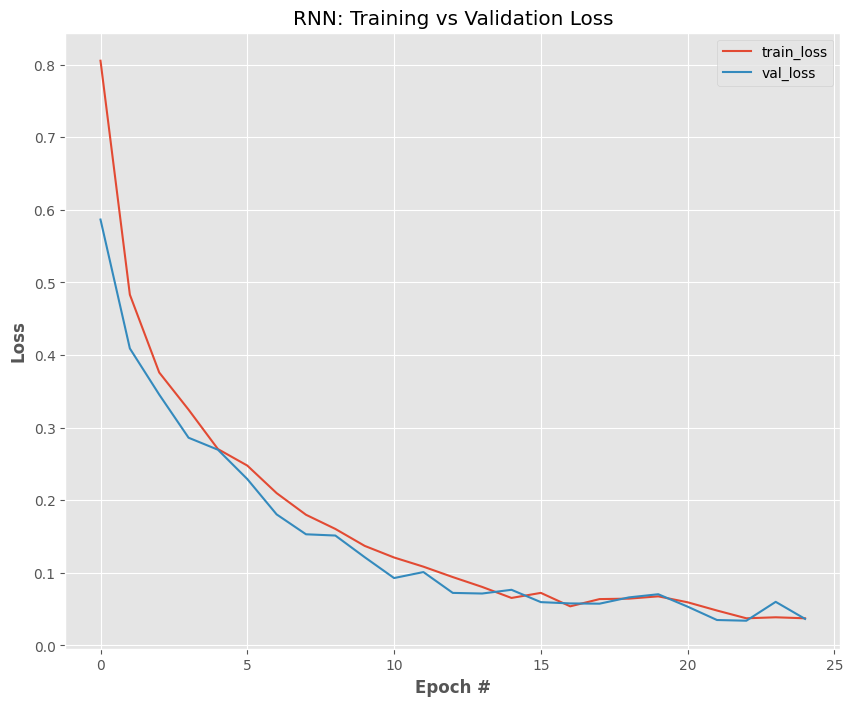

In [114]:
# plot the training and validation loss

N =np.arange(0, EPOCHS)
plt.style.use("ggplot")
plt.figure(figsize =[10,8])
plt.plot(N, result.history["loss"],label ="train_loss")
plt.plot(N, result.history['val_loss'], label ='val_loss')
plt.title("RNN: Training vs Validation Loss")
plt.xlabel("Epoch #", weight ='bold')
plt.ylabel("Loss", weight ='bold')
plt.legend()
plt.show()

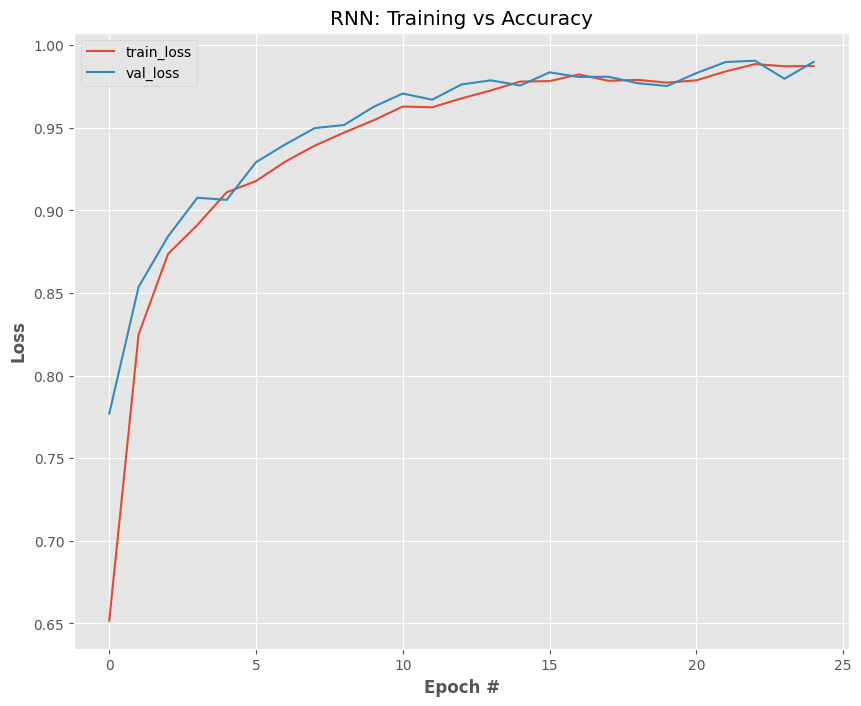

In [115]:
# plot the training and accuracy

N =np.arange(0, EPOCHS)
plt.style.use("ggplot")
plt.figure(figsize =[10,8])
plt.plot(N, result.history["accuracy"],label ="train_loss")
plt.plot(N, result.history['val_accuracy'], label ='val_loss')
plt.title("RNN: Training vs Accuracy")
plt.xlabel("Epoch #", weight ='bold')
plt.ylabel("Loss", weight ='bold')
plt.legend()
plt.show()

In [117]:
# Predict on a sample text to find out the sentiment

sample_text = "The kgf movie is excellent and it's really worth to watch in theatres"

prediction = model.predict(np.array([sample_text]))
print(prediction)

# Add final prediction to dataframe

if np.argmax(prediction) ==0:
  print("Neutral")
elif np.argmax(prediction) ==1:
  print("Positive")
else:
  print("Negative")

1/1 [==============================] - 0s 21ms/step
[[1.5234167e-05 9.9993575e-01 4.8969734e-05]]
Positive


In [119]:
#2 Predict on a sample text to find out the sentiment

sample_text = "instead of watching movie, we can sleep in ac in theatre"

prediction = model.predict(np.array([sample_text]))
print(prediction)

# Add final prediction to dataframe

if np.argmax(prediction) ==0:
  print("Neutral")
elif np.argmax(prediction) ==1:
  print("Positive")
else:
  print("Negative")

1/1 [==============================] - 0s 34ms/step
[[9.9974936e-01 2.3701521e-04 1.3613177e-05]]
Neutral


In [120]:
#3 Predict on a sample text to find out the sentiment

sample_text = "worst experience in meeting"

prediction = model.predict(np.array([sample_text]))
print(prediction)

# Add final prediction to dataframe

if np.argmax(prediction) ==0:
  print("Neutral")
elif np.argmax(prediction) ==1:
  print("Positive")
else:
  print("Negative")

1/1 [==============================] - 0s 26ms/step
[[3.3317292e-06 1.8254252e-05 9.9997842e-01]]
Negative


## Simillarly we have to do the same process for test data as we have done only for train data in the above

In [122]:
# save the file in the below format for pickle usage and to know tha architecture
model.save("Sentiment_RNN.model",save_format ="h5")


NotImplementedError: Save or restore weights that is not an instance of `tf.Variable` is not supported in h5, use `save_format='tf'` instead. Received a model or layer TextVectorization with weights [<keras.src.layers.preprocessing.index_lookup.VocabWeightHandler object at 0x7d4b227c6ad0>]